# Proyecto II — Visualización de Datos
## Copa Mundial de la FIFA

Este notebook toma el dataset ya limpio y procesado en el EDA y construye tres
visualizaciones, cada una pensada para responder una **pregunta o "historia"** concreta
sobre la Copa Mundial:

1. ¿En qué Mundiales se ha visto el fútbol más ofensivo?
2. ¿Cuáles son las verdaderas potencias históricas?
3. ¿El país que juega en casa realmente gana más?

Se usan **Seaborn/Matplotlib** para los gráficos estáticos y **Plotly** para el gráfico
interactivo.

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
from src.visualizacion.visualizador import Visualizador

## 1. Carga de datos procesados

Leemos el CSV generado por el notebook de EDA y lo pasamos a la clase `Visualizador`,
que ya trae configurada la estética global de los gráficos.

In [2]:
df_limpio = pd.read_csv("../data/processed/partidos-limpios.csv")
viz = Visualizador(df_limpio)

print(f"Partidos disponibles para graficar: {len(df_limpio)}")
df_limpio.head()

Partidos disponibles para graficar: 1068


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,anio,total_goles,diferencia_goles,ganador
0,1930-07-13,Belgium,United States,0,3,FIFA World Cup,Montevideo,Uruguay,True,1930,3,-3,Visitante
1,1930-07-13,France,Mexico,4,1,FIFA World Cup,Montevideo,Uruguay,True,1930,5,3,Local
2,1930-07-14,Brazil,Yugoslavia,1,2,FIFA World Cup,Montevideo,Uruguay,True,1930,3,-1,Visitante
3,1930-07-14,Peru,Romania,1,3,FIFA World Cup,Montevideo,Uruguay,True,1930,4,-2,Visitante
4,1930-07-15,Argentina,France,1,0,FIFA World Cup,Montevideo,Uruguay,True,1930,1,1,Local


## 2. Historia 1 — La evolución de los goles

**Pregunta:** ¿En qué ediciones del Mundial se vio el fútbol más ofensivo?

El siguiente gráfico muestra la evolución del **promedio de goles por partido** a lo largo
de los años. Permite ver si el fútbol de Mundiales se ha vuelto más o menos goleador con
el tiempo.

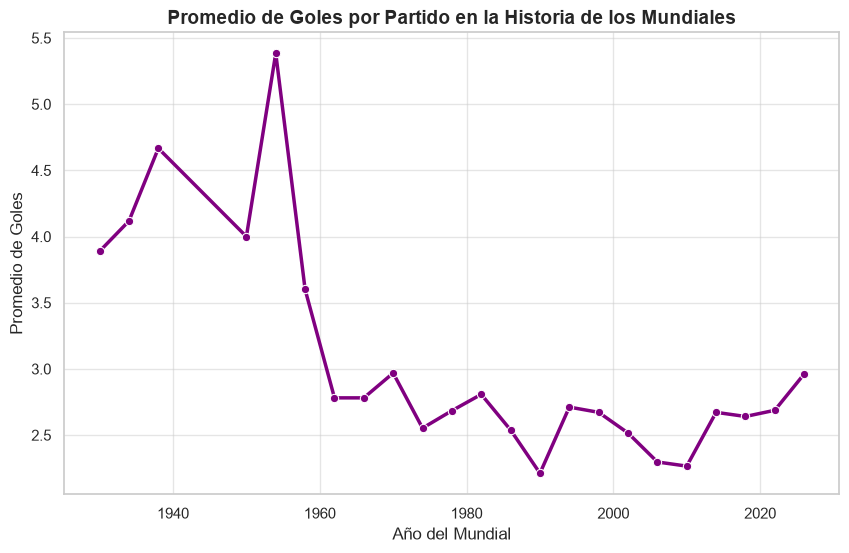

In [3]:
viz.graficar_goles_por_edicion()

**Lectura:** las primeras ediciones (años 50) muestran los promedios de goles más altos,
seguidos de una tendencia general a la baja y a la estabilización en el fútbol moderno,
más táctico y equilibrado.

## 3. Historia 2 — Las potencias históricas

**Pregunta:** ¿Cuáles son las selecciones dominantes a lo largo de la historia?

Aquí se acumula la **diferencia de goles** (goles a favor menos goles en contra) de cada
selección en toda su historia mundialista, y se muestra el Top de las más dominantes.

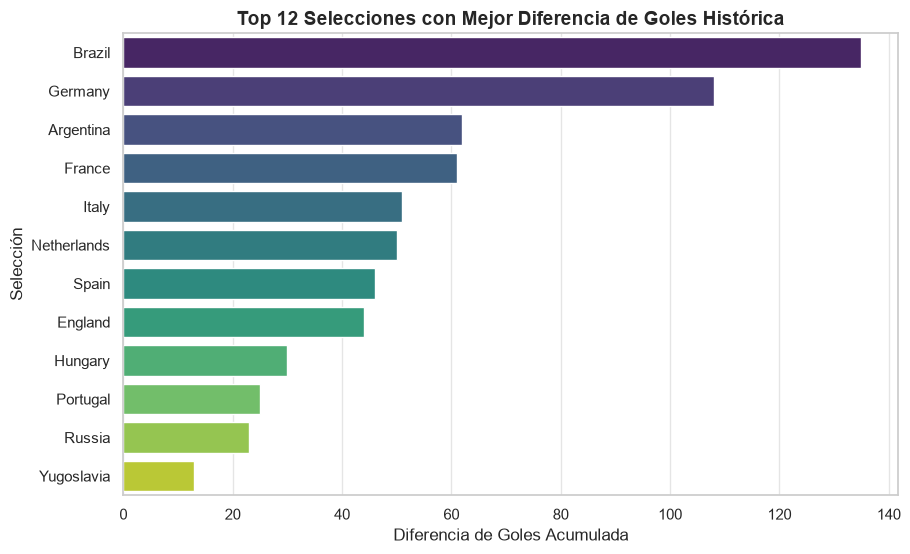

In [4]:
viz.graficar_mejor_diferencia_goles(top_n=12)

**Lectura:** las selecciones con mayor diferencia de goles acumulada coinciden con las
potencias tradicionales del fútbol mundial, aquellas con más participaciones y títulos.

## 4. Historia 3 — El efecto de la localía (interactivo)

**Pregunta:** cuando un equipo juega realmente en casa (partidos no neutrales),
¿gana más veces?

Este gráfico de dona **interactivo** (Plotly) muestra la distribución de resultados
—victoria local, visitante o empate— filtrando únicamente los partidos donde el equipo
local es el verdadero anfitrión.

In [5]:
fig = viz.graficar_efecto_sede_plotly()
fig.show()

**Lectura:** la proporción de victorias del equipo local supera claramente a la de
visitantes y empates, lo que ofrece evidencia a favor de la **ventaja de jugar en casa**
en la Copa Mundial.

## Conclusiones de la visualización

- El promedio de goles por partido fue mayor en las primeras ediciones y se ha estabilizado
  en el fútbol moderno.
- Las potencias históricas por diferencia de goles corresponden a las selecciones más
  laureadas.
- Existe una **ventaja de localía** observable: el anfitrión gana con más frecuencia que
  la que obtendría por azar.